## 04 — Regression Modeling

**Objective:** Predict each player's `rating_title` (FotMob match rating) from their 5-match rolling performance features. Trained on seasons 2021/22–2023/24, evaluated on 2024/25.

### Outfield Players
1. Load scaled train/test parquets and define feature/target columns
2. Establish mean predictor baseline (MSE, RMSE, R²)
3. Fit Ridge regression with TimeSeriesSplit cross-validation to tune `alpha`
4. Fit Random Forest regressor with TimeSeriesSplit cross-validation to tune `n_estimators` and `max_depth`
5. Evaluate both models on test set — MSE, RMSE, R²
6. Compare baseline vs Ridge vs Random Forest in summary table
7. Plot Ridge coefficients — features with strongest positive/negative effect on rating
8. Plot Random Forest feature importances — most informative features
9. Plot predicted vs actual rating_title (residual analysis)
10. Check residuals by position group for systematic bias

### Goalkeepers
11. Repeat steps 2–9 for GK using GK-specific features
12. Compare outfield vs GK model performance

### Export
13. Save Ridge and Random Forest models to `data/models/`
14. Save train and test predictions as new columns in parquets to `data/processed/datasets/`

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
from pathlib import Path
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

warnings.filterwarnings('ignore')

PROCESSED_DIR = Path('data/processed/datasets')
MODELS_DIR    = Path('data/models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

outfield_train = pd.read_parquet(PROCESSED_DIR / 'outfield_train_scaled.parquet')
outfield_test  = pd.read_parquet(PROCESSED_DIR / 'outfield_test_scaled.parquet')
gk_train       = pd.read_parquet(PROCESSED_DIR / 'gk_train_scaled.parquet')
gk_test        = pd.read_parquet(PROCESSED_DIR / 'gk_test_scaled.parquet')

ID_COLS = [
    'match_id', 'round', 'match_date', 'home_team', 'away_team',
    'player_id', 'player_name', 'team_id', 'team_name', 'minutes_played',
    'shirt_number', 'position_id', 'is_goalkeeper', 'season',
    'opponent', 'team_goals_scored', 'opp_goals_scored', 'result',
    'position_group'
]

print(f'Outfield train : {outfield_train.shape[0]:,} rows x {outfield_train.shape[1]} cols')
print(f'Outfield test  : {outfield_test.shape[0]:,} rows x {outfield_test.shape[1]} cols')
print(f'GK train       : {gk_train.shape[0]:,} rows x {gk_train.shape[1]} cols')
print(f'GK test        : {gk_test.shape[0]:,} rows x {gk_test.shape[1]} cols')

Outfield train : 21,847 rows x 57 cols
Outfield test  : 7,034 rows x 57 cols
GK train       : 2,193 rows x 47 cols
GK test        : 713 rows x 47 cols


In [162]:
# ── Cross-validation setup ────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5)

# ── Alpha grid ────────────────────────────────────────────────
ALPHAS = [0.1, 1.0, 10.0, 100.0, 200.0, 500.0, 750.0, 1000.0, 2000.0, 5000.0]

# ── Outfield RF — focused around known sweet spot ─────────────
# Drops depth 4-6 (consistently underfit) and 100 estimators (always loses)
# Adds 750 to check if gains plateau before 700
RF_PARAM_GRID = [
    {'n_estimators': n, 'max_depth': d}
    for n in [200, 300, 500]
    for d in [4, 5, 6, 7, 8]
]

# GK RF — shallow grid, small dataset
# Drops depth 6-7 (overfit on ~2,200 rows)
# Keeps 100 estimators since small data doesn't need many trees
RF_PARAM_GRID_GK = [
    {'n_estimators': n, 'max_depth': d}
    for n in [100, 200, 300, 500]
    for d in [3, 4, 5]
]

GROUPS      = ['defender', 'midfielder', 'winger', 'forward']
GROUP_COLS  = {
    'defender'  : '#2171b5',
    'midfielder': '#238b45',
    'winger'    : '#d94801',
    'forward'   : '#6a51a3'
}

# ── Helper functions ──────────────────────────────────────────
def evaluate(y_true, y_pred, label):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f'  {label:<45} MSE:{mse:.4f}  RMSE:{rmse:.4f}  R²:{r2:.4f}')
    return {'label': label, 'mse': mse, 'rmse': rmse, 'r2': r2}

def print_results_table(results, title=''):
    if title:
        print(f'\n{"="*72}')
        print(f'  {title}')
        print(f'{"="*72}')
    print(f'  {"Model":<45} {"MSE":>8} {"RMSE":>8} {"R²":>8}')
    print(f'  {"-"*70}')
    for r in results:
        print(f'  {r["label"]:<45} {r["mse"]:>8.4f} {r["rmse"]:>8.4f} {r["r2"]:>8.4f}')

print(f'Alpha grid     : {ALPHAS}')
print(f'RF combinations: {len(RF_PARAM_GRID)}')
print(f'RF combinations (GK): {len(RF_PARAM_GRID_GK)}')

Alpha grid     : [0.1, 1.0, 10.0, 100.0, 200.0, 500.0, 750.0, 1000.0, 2000.0, 5000.0]
RF combinations: 15
RF combinations (GK): 12


In [163]:
# Baseline features — rolling stats only, no context features
FEATURE_COLS_OUT = [c for c in outfield_train.columns
                    if c not in ID_COLS + ['rating_title',
                                           'home_away',
                                           'self_strength',
                                           'opp_strength',
                                           'opp_attack_strength']]

FEATURE_COLS_GK  = [c for c in gk_train.columns
                    if c not in ID_COLS + ['rating_title',
                                           'home_away',
                                           'self_strength',
                                           'opp_strength',
                                           'opp_attack_strength']]

# X and y arrays
X_train_out = outfield_train[FEATURE_COLS_OUT].values
X_test_out  = outfield_test[FEATURE_COLS_OUT].values
y_train_out = outfield_train['rating_title'].values
y_test_out  = outfield_test['rating_title'].values

X_train_gk  = gk_train[FEATURE_COLS_GK].values
X_test_gk   = gk_test[FEATURE_COLS_GK].values
y_train_gk  = gk_train['rating_title'].values
y_test_gk   = gk_test['rating_title'].values

print(f'Outfield features : {len(FEATURE_COLS_OUT)}')
print(f'GK features       : {len(FEATURE_COLS_GK)}')
# print(f'\nFeature list (outfield):')
# for c in FEATURE_COLS_OUT:
#     print(f'  {c}')

Outfield features : 36
GK features       : 26


In [164]:
print('=' * 72)
print('  STAGE 1 — Mean predictor baselines')
print('=' * 72)

results_baseline = []

results_baseline.append(evaluate(
    y_test_out, np.full_like(y_test_out, y_train_out.mean()), 'Baseline mean — Outfield'))
results_baseline.append(evaluate(
    y_test_gk,  np.full_like(y_test_gk,  y_train_gk.mean()),  'Baseline mean — GK'))

print(f'\n  Outfield train mean rating : {y_train_out.mean():.4f}')
print(f'  GK train mean rating       : {y_train_gk.mean():.4f}')
print(f'\n  Note: R² ≈ 0 by definition for mean predictor.')
print(f'        Any real model must beat these RMSE values:')
print(f'        Outfield RMSE floor: {np.sqrt(mean_squared_error(y_test_out, np.full_like(y_test_out, y_train_out.mean()))):.4f}')
print(f'        GK RMSE floor      : {np.sqrt(mean_squared_error(y_test_gk, np.full_like(y_test_gk, y_train_gk.mean()))):.4f}')

  STAGE 1 — Mean predictor baselines
  Baseline mean — Outfield                      MSE:0.6312  RMSE:0.7944  R²:-0.0011
  Baseline mean — GK                            MSE:1.3301  RMSE:1.1533  R²:-0.0031

  Outfield train mean rating : 7.0281
  GK train mean rating       : 6.8017

  Note: R² ≈ 0 by definition for mean predictor.
        Any real model must beat these RMSE values:
        Outfield RMSE floor: 0.7944
        GK RMSE floor      : 1.1533


In [165]:
print('=' * 72)
print('  STAGE 2 — Ridge regression, single model (baseline features)')
print('=' * 72)

results_ridge_single = []

# Outfield
print('\n── Outfield ──')
ridge_single_out = RidgeCV(alphas=ALPHAS, cv=tscv, scoring='neg_mean_squared_error')
ridge_single_out.fit(X_train_out, y_train_out)
y_pred_ridge_single_out = ridge_single_out.predict(X_test_out)
results_ridge_single.append(evaluate(y_test_out, y_pred_ridge_single_out, 'Ridge single — Outfield'))
print(f'  Best alpha: {ridge_single_out.alpha_}')

cv_out = cross_val_score(Ridge(alpha=ridge_single_out.alpha_),
                         X_train_out, y_train_out,
                         cv=tscv, scoring='neg_root_mean_squared_error')
print(f'  CV RMSE per fold : {-cv_out.round(4)} | mean: {-cv_out.mean():.4f}')

# GK
print('\n── GK ──')
ridge_single_gk = RidgeCV(alphas=ALPHAS, cv=tscv, scoring='neg_mean_squared_error')
ridge_single_gk.fit(X_train_gk, y_train_gk)
y_pred_ridge_single_gk = ridge_single_gk.predict(X_test_gk)
results_ridge_single.append(evaluate(y_test_gk, y_pred_ridge_single_gk, 'Ridge single — GK'))
print(f'  Best alpha: {ridge_single_gk.alpha_}')

cv_gk = cross_val_score(Ridge(alpha=ridge_single_gk.alpha_),
                        X_train_gk, y_train_gk,
                        cv=tscv, scoring='neg_root_mean_squared_error')
print(f'  CV RMSE per fold : {-cv_gk.round(4)} | mean: {-cv_gk.mean():.4f}')

print_results_table(results_ridge_single, 'Ridge single model — baseline features')

  STAGE 2 — Ridge regression, single model (baseline features)

── Outfield ──
  Ridge single — Outfield                       MSE:0.6027  RMSE:0.7764  R²:0.0440
  Best alpha: 2000.0
  CV RMSE per fold : [0.8077 0.805  0.7739 0.8081 0.7264] | mean: 0.7842

── GK ──
  Ridge single — GK                             MSE:1.3147  RMSE:1.1466  R²:0.0085
  Best alpha: 200.0
  CV RMSE per fold : [1.1319 1.0796 1.118  1.061  1.1133] | mean: 1.1008

  Ridge single model — baseline features
  Model                                              MSE     RMSE       R²
  ----------------------------------------------------------------------
  Ridge single — Outfield                         0.6027   0.7764   0.0440
  Ridge single — GK                               1.3147   1.1466   0.0085


In [166]:
print('=' * 72)
print('  STAGE 3 — Random Forest, single model, exhaustive grid (baseline features)')
print('=' * 72)

results_rf_single = []

def exhaustive_rf_search(X_tr, y_tr, label, param_grid):
    best_params = None
    best_rmse   = np.inf
    all_results = []

    print(f'\n── {label} — {len(param_grid)} combinations ──')
    print(f'  {"n_est":<8} {"depth":<8} {"CV RMSE":>10} {"CV STD":>8}')
    print(f'  {"-"*36}')

    for params in param_grid:
        rf     = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
        scores = cross_val_score(rf, X_tr, y_tr, cv=tscv,
                                 scoring='neg_root_mean_squared_error')
        mean_rmse = -scores.mean()
        std_rmse  = scores.std()
        all_results.append({**params, 'cv_rmse': mean_rmse, 'cv_std': std_rmse})

        marker = ' ◄' if mean_rmse < best_rmse else ''
        print(f'  {params["n_estimators"]:<8} {str(params["max_depth"]):<8} '
              f'{mean_rmse:>10.4f} {std_rmse:>8.4f}{marker}')

        if mean_rmse < best_rmse:
            best_rmse   = mean_rmse
            best_params = params

    print(f'\n  Best: {best_params} | CV RMSE: {best_rmse:.4f}')
    return best_params, pd.DataFrame(all_results)

# Outfield — standard grid
best_params_out_single, grid_df_out_single = exhaustive_rf_search(
    X_train_out, y_train_out, 'Outfield', RF_PARAM_GRID)

rf_single_out = RandomForestRegressor(**best_params_out_single, random_state=42, n_jobs=-1)
rf_single_out.fit(X_train_out, y_train_out)
y_pred_rf_single_out = rf_single_out.predict(X_test_out)
results_rf_single.append(evaluate(y_test_out, y_pred_rf_single_out, 'RF single — Outfield'))

# GK — shallower grid, limited data
best_params_gk_single, grid_df_gk_single = exhaustive_rf_search(
    X_train_gk, y_train_gk, 'GK', RF_PARAM_GRID_GK)

rf_single_gk = RandomForestRegressor(**best_params_gk_single, random_state=42, n_jobs=-1)
rf_single_gk.fit(X_train_gk, y_train_gk)
y_pred_rf_single_gk = rf_single_gk.predict(X_test_gk)
results_rf_single.append(evaluate(y_test_gk, y_pred_rf_single_gk, 'RF single — GK'))

print_results_table(results_rf_single, 'RF single model — baseline features')

  STAGE 3 — Random Forest, single model, exhaustive grid (baseline features)

── Outfield — 15 combinations ──
  n_est    depth       CV RMSE   CV STD
  ------------------------------------
  200      4            0.7874   0.0314 ◄
  200      5            0.7863   0.0318 ◄
  200      6            0.7860   0.0320 ◄
  200      7            0.7861   0.0324
  200      8            0.7864   0.0327
  300      4            0.7873   0.0315
  300      5            0.7864   0.0319
  300      6            0.7861   0.0321
  300      7            0.7862   0.0324
  300      8            0.7863   0.0326
  500      4            0.7873   0.0314
  500      5            0.7864   0.0319
  500      6            0.7862   0.0321
  500      7            0.7863   0.0323
  500      8            0.7864   0.0325

  Best: {'n_estimators': 200, 'max_depth': 6} | CV RMSE: 0.7860
  RF single — Outfield                          MSE:0.5920  RMSE:0.7694  R²:0.0610

── GK — 12 combinations ──
  n_est    depth       CV RM

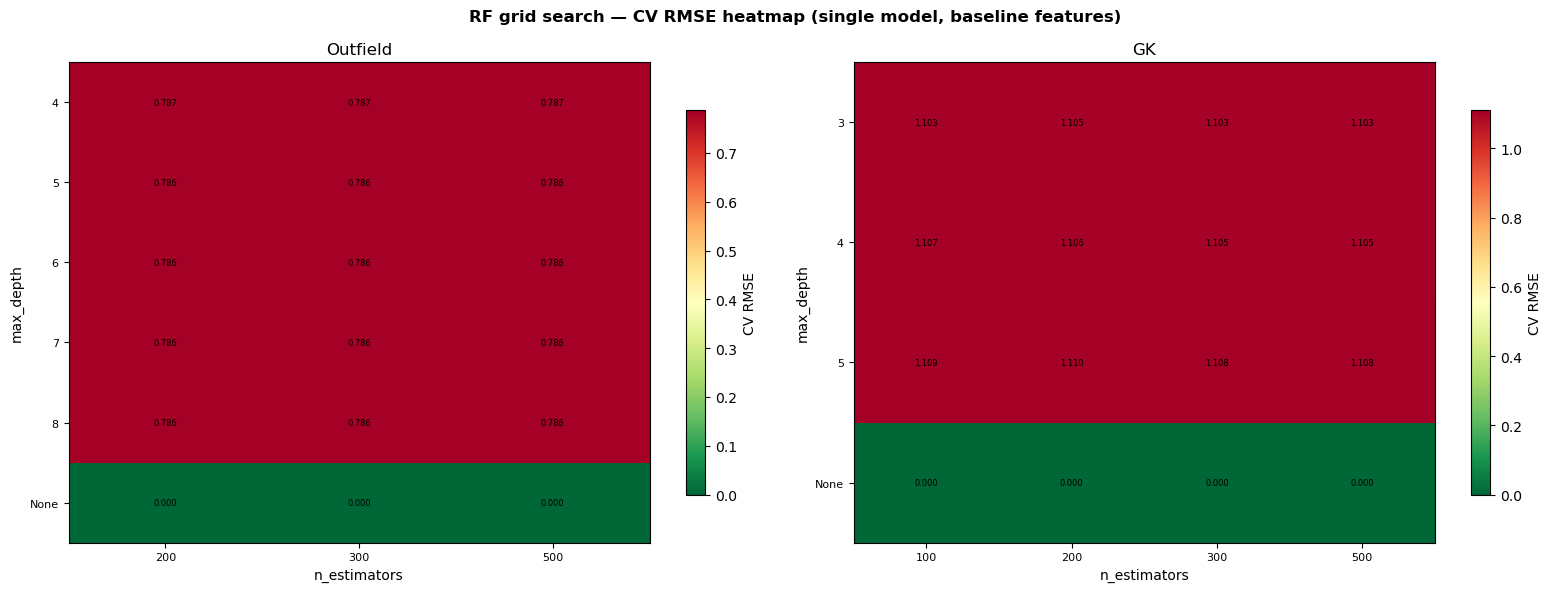

In [167]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RF grid search — CV RMSE heatmap (single model, baseline features)',
             fontsize=12, fontweight='bold')

for ax, (df_grid, label) in zip(axes, [
    (grid_df_out_single, 'Outfield'),
    (grid_df_gk_single,  'GK')
]):
    n_vals = sorted(df_grid['n_estimators'].unique())
    d_vals = sorted([d for d in df_grid['max_depth'].unique() if d is not None]) + [None]
    matrix = np.zeros((len(d_vals), len(n_vals)))

    for i, d in enumerate(d_vals):
        for j, n in enumerate(n_vals):
            val = df_grid[(df_grid['n_estimators'] == n) &
                          (df_grid['max_depth'] == d)]['cv_rmse'].values
            if len(val) > 0:
                matrix[i, j] = val[0]

    im = ax.imshow(matrix, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(len(n_vals)))
    ax.set_xticklabels(n_vals, fontsize=8)
    ax.set_yticks(range(len(d_vals)))
    ax.set_yticklabels([str(d) for d in d_vals], fontsize=8)
    ax.set_xlabel('n_estimators')
    ax.set_ylabel('max_depth')
    ax.set_title(f'{label}')

    for i in range(len(d_vals)):
        for j in range(len(n_vals)):
            ax.text(j, i, f'{matrix[i,j]:.3f}', ha='center', va='center',
                    fontsize=6, color='black')
    plt.colorbar(im, ax=ax, shrink=0.8, label='CV RMSE')

plt.tight_layout()
plt.savefig(MODELS_DIR / 'rf_grid_single_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [168]:
print('=' * 72)
print('  STAGE 4 — Ridge regression, position-grouped (baseline features)')
print('=' * 72)

results_ridge_grouped = []
ridge_grouped_models  = {}

for group in GROUPS:
    train_g = outfield_train[outfield_train['position_group'] == group]
    test_g  = outfield_test[outfield_test['position_group']  == group]
    X_tr    = train_g[FEATURE_COLS_OUT].values
    y_tr    = train_g['rating_title'].values
    X_te    = test_g[FEATURE_COLS_OUT].values
    y_te    = test_g['rating_title'].values

    print(f'\n── {group.upper()} ({len(train_g):,} train | {len(test_g):,} test) ──')

    ridge = RidgeCV(alphas=ALPHAS, cv=tscv, scoring='neg_mean_squared_error')
    ridge.fit(X_tr, y_tr)
    y_pred = ridge.predict(X_te)
    r = evaluate(y_te, y_pred, f'Ridge grouped — {group}')
    results_ridge_grouped.append(r)
    ridge_grouped_models[group] = ridge
    print(f'  Best alpha: {ridge.alpha_}')

    cv = cross_val_score(Ridge(alpha=ridge.alpha_), X_tr, y_tr,
                         cv=tscv, scoring='neg_root_mean_squared_error')
    print(f'  CV RMSE per fold: {-cv.round(4)} | mean: {-cv.mean():.4f}')

print_results_table(results_ridge_grouped, 'Ridge position-grouped — baseline features')
avg_r2 = np.mean([r['r2'] for r in results_ridge_grouped])
print(f'\n  Average R² across groups: {avg_r2:.4f}')

  STAGE 4 — Ridge regression, position-grouped (baseline features)

── DEFENDER (9,548 train | 3,029 test) ──
  Ridge grouped — defender                      MSE:0.5724  RMSE:0.7566  R²:0.0355
  Best alpha: 2000.0
  CV RMSE per fold: [0.7481 0.7718 0.7555 0.7887 0.7127] | mean: 0.7554

── MIDFIELDER (6,764 train | 2,181 test) ──
  Ridge grouped — midfielder                    MSE:0.5736  RMSE:0.7573  R²:0.0667
  Best alpha: 750.0
  CV RMSE per fold: [0.8073 0.7663 0.7946 0.7529 0.703 ] | mean: 0.7648

── WINGER (3,110 train | 1,077 test) ──
  Ridge grouped — winger                        MSE:0.6025  RMSE:0.7762  R²:0.0341
  Best alpha: 2000.0
  CV RMSE per fold: [0.8171 0.7977 0.7907 0.7937 0.6885] | mean: 0.7775

── FORWARD (2,425 train | 747 test) ──
  Ridge grouped — forward                       MSE:0.7189  RMSE:0.8479  R²:0.0696
  Best alpha: 1000.0
  CV RMSE per fold: [0.9034 0.9673 0.8837 0.9998 0.8585] | mean: 0.9225

  Ridge position-grouped — baseline features
  Model        

In [169]:
print('=' * 72)
print('  STAGE 5 — RF exhaustive grid, position-grouped (baseline features)')
print('=' * 72)

results_rf_grouped   = []
rf_grouped_models    = {}
grid_results_grouped = {}

for group in GROUPS:
    train_g = outfield_train[outfield_train['position_group'] == group]
    test_g  = outfield_test[outfield_test['position_group']  == group]
    X_tr    = train_g[FEATURE_COLS_OUT].values
    y_tr    = train_g['rating_title'].values
    X_te    = test_g[FEATURE_COLS_OUT].values
    y_te    = test_g['rating_title'].values

    best_params, grid_df = exhaustive_rf_search(X_tr, y_tr, group.upper(), RF_PARAM_GRID)
    grid_results_grouped[group] = grid_df

    rf = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_te)
    r = evaluate(y_te, y_pred, f'RF grouped — {group}')
    results_rf_grouped.append(r)
    rf_grouped_models[group] = {'model': rf, 'params': best_params}

print_results_table(results_rf_grouped, 'RF position-grouped — baseline features')
print(f'\n  Average R² across groups: {np.mean([r["r2"] for r in results_rf_grouped]):.4f}')
print(f'\n── Best params per group ──')
for group in GROUPS:
    p = rf_grouped_models[group]['params']
    r = next(r for r in results_rf_grouped if group in r['label'])
    print(f'  {group:<12} n={p["n_estimators"]:<5} d={p["max_depth"]:<4} R²={r["r2"]:.4f}')

  STAGE 5 — RF exhaustive grid, position-grouped (baseline features)

── DEFENDER — 15 combinations ──
  n_est    depth       CV RMSE   CV STD
  ------------------------------------
  200      4            0.7582   0.0260 ◄
  200      5            0.7581   0.0257 ◄
  200      6            0.7582   0.0256
  200      7            0.7590   0.0255
  200      8            0.7597   0.0258
  300      4            0.7580   0.0261 ◄
  300      5            0.7580   0.0258 ◄
  300      6            0.7581   0.0257
  300      7            0.7590   0.0258
  300      8            0.7598   0.0260
  500      4            0.7578   0.0259 ◄
  500      5            0.7579   0.0256
  500      6            0.7581   0.0256
  500      7            0.7589   0.0257
  500      8            0.7597   0.0258

  Best: {'n_estimators': 500, 'max_depth': 4} | CV RMSE: 0.7578
  RF grouped — defender                         MSE:0.5647  RMSE:0.7514  R²:0.0485

── MIDFIELDER — 15 combinations ──
  n_est    depth       C

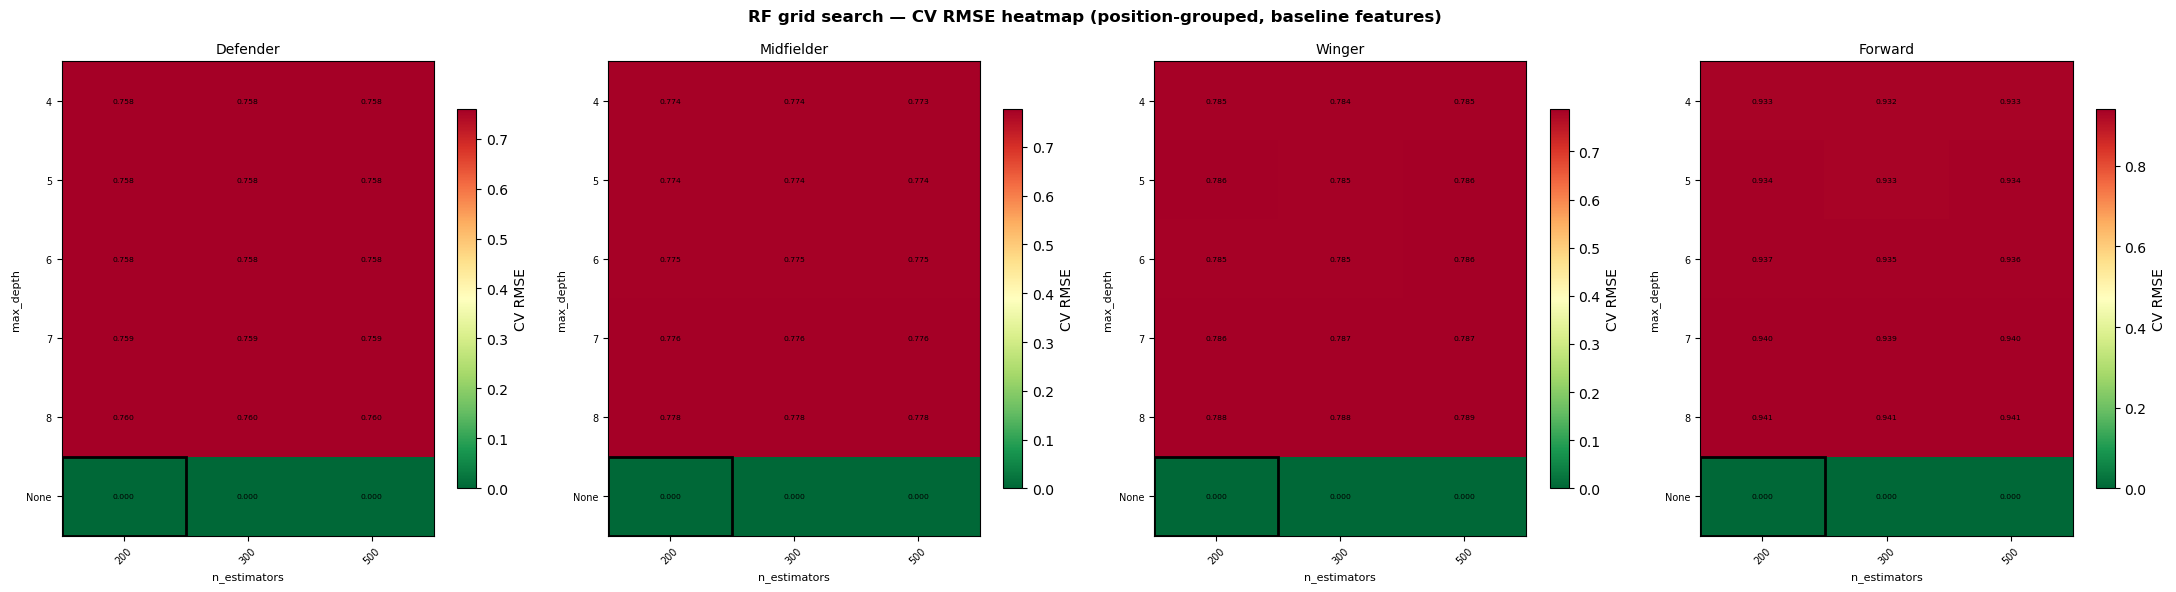

In [170]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle('RF grid search — CV RMSE heatmap (position-grouped, baseline features)',
             fontsize=12, fontweight='bold')

for ax, group in zip(axes, GROUPS):
    df_grid = grid_results_grouped[group]
    n_vals  = sorted(df_grid['n_estimators'].unique())
    d_vals  = sorted([d for d in df_grid['max_depth'].unique() if d is not None]) + [None]
    matrix  = np.zeros((len(d_vals), len(n_vals)))

    for i, d in enumerate(d_vals):
        for j, n in enumerate(n_vals):
            val = df_grid[(df_grid['n_estimators'] == n) &
                          (df_grid['max_depth'] == d)]['cv_rmse'].values
            if len(val) > 0:
                matrix[i, j] = val[0]

    im = ax.imshow(matrix, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(len(n_vals)))
    ax.set_xticklabels(n_vals, fontsize=7, rotation=45)
    ax.set_yticks(range(len(d_vals)))
    ax.set_yticklabels([str(d) for d in d_vals], fontsize=7)
    ax.set_xlabel('n_estimators', fontsize=8)
    ax.set_ylabel('max_depth', fontsize=8)
    ax.set_title(f'{group.capitalize()}', fontsize=10)

    # Mark best cell
    best_idx = np.unravel_index(matrix.argmin(), matrix.shape)
    ax.add_patch(plt.Rectangle((best_idx[1]-0.5, best_idx[0]-0.5),
                                1, 1, fill=False, edgecolor='black', lw=2))

    for i in range(len(d_vals)):
        for j in range(len(n_vals)):
            ax.text(j, i, f'{matrix[i,j]:.3f}', ha='center', va='center',
                    fontsize=5.5, color='black')
    plt.colorbar(im, ax=ax, shrink=0.8, label='CV RMSE')

plt.tight_layout()
plt.savefig(MODELS_DIR / 'rf_grid_grouped_baseline_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [171]:
print('=' * 72)
print('  BASELINE FEATURES — FULL SUMMARY')
print('=' * 72)

print('\n── Single model ──')
print_results_table(results_baseline + results_ridge_single + results_rf_single)

print('\n── Position-grouped ──')
print_results_table(results_ridge_grouped + results_rf_grouped)

print('\n── Improvement: single → grouped RF ──')
single_rf_r2  = next(r['r2'] for r in results_rf_single if 'Outfield' in r['label'])
grouped_rf_r2 = np.mean([r['r2'] for r in results_rf_grouped])
print(f'  Single RF R²  : {single_rf_r2:.4f}')
print(f'  Grouped RF R² : {grouped_rf_r2:.4f}  (avg across positions)')
print(f'  Improvement   : +{grouped_rf_r2 - single_rf_r2:.4f}')
print(f'\n  Conclusion: baseline features achieve limited R² — adding context features next.')

  BASELINE FEATURES — FULL SUMMARY

── Single model ──
  Model                                              MSE     RMSE       R²
  ----------------------------------------------------------------------
  Baseline mean — Outfield                        0.6312   0.7944  -0.0011
  Baseline mean — GK                              1.3301   1.1533  -0.0031
  Ridge single — Outfield                         0.6027   0.7764   0.0440
  Ridge single — GK                               1.3147   1.1466   0.0085
  RF single — Outfield                            0.5920   0.7694   0.0610
  RF single — GK                                  1.3126   1.1457   0.0102

── Position-grouped ──
  Model                                              MSE     RMSE       R²
  ----------------------------------------------------------------------
  Ridge grouped — defender                        0.5724   0.7566   0.0355
  Ridge grouped — midfielder                      0.5736   0.7573   0.0667
  Ridge grouped — winger 

In [172]:
print('=' * 72)
print('  STAGE 6 — Build enhanced features')
print('=' * 72)

# ── Rolling team strength from goals scored/conceded ──────────
all_matches = pd.concat([
    outfield_train[['match_id', 'match_date', 'team_name',
                    'team_goals_scored', 'opp_goals_scored']].drop_duplicates(),
    outfield_test[['match_id', 'match_date', 'team_name',
                   'team_goals_scored', 'opp_goals_scored']].drop_duplicates()
]).drop_duplicates().sort_values(['team_name', 'match_date']).reset_index(drop=True)

all_matches['self_strength'] = (
    all_matches.groupby('team_name')['team_goals_scored']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)
all_matches['opp_strength'] = (
    all_matches.groupby('team_name')['opp_goals_scored']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)
opp_lookup = all_matches[['match_id', 'team_name', 'self_strength']].rename(
    columns={'team_name': 'opponent', 'self_strength': 'opp_attack_strength'}
)

# ── Apply strength features ──────────────────
for df_name in ['outfield_train', 'outfield_test']:
    df = globals()[df_name]
    for col in ['self_strength', 'opp_strength', 'opp_attack_strength']:
        if col in df.columns:
            df = df.drop(columns=[col])
    df = df.merge(
        all_matches[['match_id', 'team_name', 'self_strength', 'opp_strength']],
        on=['match_id', 'team_name'], how='left'
    )
    df = df.merge(opp_lookup, on=['match_id', 'opponent'], how='left')
    fill_vals = df[['self_strength', 'opp_strength', 'opp_attack_strength']].mean()
    df[['self_strength', 'opp_strength', 'opp_attack_strength']] = \
        df[['self_strength', 'opp_strength', 'opp_attack_strength']].fillna(fill_vals)
    globals()[df_name] = df

# ── Enhanced feature columns ──────────────────────────────────
ENH_NON_FEATURE = [
    'match_id', 'round', 'match_date', 'home_team', 'away_team',
    'player_id', 'player_name', 'team_id', 'team_name',
    'shirt_number', 'position_id', 'is_goalkeeper', 'season',
    'opponent', 'team_goals_scored', 'opp_goals_scored', 'result',
    'position_group', 'rating_title', 'minutes_played'
]

FEATURE_COLS_ENH_OUT = [c for c in outfield_train.columns if c not in ENH_NON_FEATURE]
# GK keeps its original feature set — no strength features added
FEATURE_COLS_ENH_GK  = [c for c in gk_train.columns if c not in ENH_NON_FEATURE]

new_features = sorted(set(FEATURE_COLS_ENH_OUT) - set(FEATURE_COLS_OUT))
print(f'Baseline outfield features  : {len(FEATURE_COLS_OUT)}')
print(f'Enhanced outfield features  : {len(FEATURE_COLS_ENH_OUT)}')
print(f'New features added          : {new_features}')

X_train_out_e = outfield_train[FEATURE_COLS_ENH_OUT].values
X_test_out_e  = outfield_test[FEATURE_COLS_ENH_OUT].values
X_train_gk_e  = gk_train[FEATURE_COLS_ENH_GK].values
X_test_gk_e   = gk_test[FEATURE_COLS_ENH_GK].values

print(f'\nX_train_out_e : {X_train_out_e.shape}')
print(f'X_train_gk_e  : {X_train_gk_e.shape}')

  STAGE 6 — Build enhanced features
Baseline outfield features  : 36
Enhanced outfield features  : 40
New features added          : ['home_away', 'opp_attack_strength', 'opp_strength', 'self_strength']

X_train_out_e : (21847, 40)
X_train_gk_e  : (2193, 27)


In [173]:
print('=' * 72)
print('  STAGE 7 — Ridge regression, single model (enhanced features)')
print('=' * 72)

results_ridge_enh_single = []

print('\n── Outfield ──')
ridge_enh_single_out = RidgeCV(alphas=ALPHAS, cv=tscv, scoring='neg_mean_squared_error')
ridge_enh_single_out.fit(X_train_out_e, y_train_out)
y_pred_ridge_enh_out = ridge_enh_single_out.predict(X_test_out_e)
results_ridge_enh_single.append(evaluate(
    y_test_out, y_pred_ridge_enh_out, 'Ridge enh single — Outfield'))
print(f'  Best alpha: {ridge_enh_single_out.alpha_}')
cv_out = cross_val_score(Ridge(alpha=ridge_enh_single_out.alpha_),
                         X_train_out_e, y_train_out,
                         cv=tscv, scoring='neg_root_mean_squared_error')
print(f'  CV RMSE per fold: {-cv_out.round(4)} | mean: {-cv_out.mean():.4f}')

print('\n── GK ──')
print(f'  GK enhanced features ({len(FEATURE_COLS_ENH_GK)}):')
for c in sorted(set(FEATURE_COLS_ENH_GK) - set(FEATURE_COLS_GK)):
    print(f'    + {c}  ← new')

ridge_enh_single_gk = RidgeCV(alphas=ALPHAS, cv=tscv, scoring='neg_mean_squared_error')
ridge_enh_single_gk.fit(X_train_gk_e, y_train_gk)
y_pred_ridge_enh_gk = ridge_enh_single_gk.predict(X_test_gk_e)
results_ridge_enh_single.append(evaluate(
    y_test_gk, y_pred_ridge_enh_gk, 'Ridge enh single — GK'))
print(f'  Best alpha: {ridge_enh_single_gk.alpha_}')
cv_gk = cross_val_score(Ridge(alpha=ridge_enh_single_gk.alpha_),
                        X_train_gk_e, y_train_gk,
                        cv=tscv, scoring='neg_root_mean_squared_error')
print(f'  CV RMSE per fold: {-cv_gk.round(4)} | mean: {-cv_gk.mean():.4f}')

print_results_table(results_ridge_enh_single, 'Ridge single — enhanced features')

  STAGE 7 — Ridge regression, single model (enhanced features)

── Outfield ──
  Ridge enh single — Outfield                   MSE:0.5786  RMSE:0.7607  R²:0.0823
  Best alpha: 750.0
  CV RMSE per fold: [0.8005 0.7916 0.7601 0.7989 0.7177] | mean: 0.7738

── GK ──
  GK enhanced features (27):
    + home_away  ← new
  Ridge enh single — GK                         MSE:1.3171  RMSE:1.1477  R²:0.0067
  Best alpha: 500.0
  CV RMSE per fold: [1.1258 1.0869 1.1201 1.0623 1.1099] | mean: 1.1010

  Ridge single — enhanced features
  Model                                              MSE     RMSE       R²
  ----------------------------------------------------------------------
  Ridge enh single — Outfield                     0.5786   0.7607   0.0823
  Ridge enh single — GK                           1.3171   1.1477   0.0067


### Cell 10 — Enhanced feature columns

In [174]:
print('=' * 72)
print('  STAGE 8 — RF single model (enhanced features)')
print('=' * 72)

results_rf_enh_single = []

# Outfield — standard grid
best_params_out_enh, grid_df_out_enh = exhaustive_rf_search(
    X_train_out_e, y_train_out, 'Outfield enhanced', RF_PARAM_GRID)

rf_enh_single_out = RandomForestRegressor(**best_params_out_enh, random_state=42, n_jobs=-1)
rf_enh_single_out.fit(X_train_out_e, y_train_out)
y_pred_rf_enh_out = rf_enh_single_out.predict(X_test_out_e)
results_rf_enh_single.append(evaluate(
    y_test_out, y_pred_rf_enh_out, 'RF enh single — Outfield'))

# GK — same baseline grid, features unchanged
print(f'\nGK features unchanged from baseline — using RF_PARAM_GRID_GK ({len(RF_PARAM_GRID_GK)} combos)')

best_params_gk_enh, grid_df_gk_enh = exhaustive_rf_search(
    X_train_gk_e, y_train_gk, 'GK enhanced', RF_PARAM_GRID_GK)

rf_enh_single_gk = RandomForestRegressor(**best_params_gk_enh, random_state=42, n_jobs=-1)
rf_enh_single_gk.fit(X_train_gk_e, y_train_gk)
y_pred_rf_enh_gk = rf_enh_single_gk.predict(X_test_gk_e)
results_rf_enh_single.append(evaluate(
    y_test_gk, y_pred_rf_enh_gk, 'RF enh single — GK'))

print_results_table(results_rf_enh_single, 'RF single — enhanced features')

print(f'\n── GK baseline vs enhanced ──')
print(f'  Baseline RF GK R²  : {results_rf_single[1]["r2"]:.4f}')
print(f'  Enhanced RF GK R²  : {results_rf_enh_single[1]["r2"]:.4f}')
change = results_rf_enh_single[1]["r2"] - results_rf_single[1]["r2"]
symbol = '+' if change >= 0 else ''
print(f'  Change             : {symbol}{change:.4f}')

  STAGE 8 — RF single model (enhanced features)

── Outfield enhanced — 15 combinations ──
  n_est    depth       CV RMSE   CV STD
  ------------------------------------
  200      4            0.7788   0.0316 ◄
  200      5            0.7763   0.0315 ◄
  200      6            0.7746   0.0321 ◄
  200      7            0.7738   0.0325 ◄
  200      8            0.7736   0.0329 ◄
  300      4            0.7788   0.0316
  300      5            0.7762   0.0316
  300      6            0.7744   0.0322
  300      7            0.7734   0.0326 ◄
  300      8            0.7732   0.0329 ◄
  500      4            0.7788   0.0315
  500      5            0.7761   0.0316
  500      6            0.7744   0.0322
  500      7            0.7734   0.0326
  500      8            0.7731   0.0329 ◄

  Best: {'n_estimators': 500, 'max_depth': 8} | CV RMSE: 0.7731
  RF enh single — Outfield                      MSE:0.5746  RMSE:0.7580  R²:0.0886

GK features unchanged from baseline — using RF_PARAM_GRID_GK (12 

In [175]:
print('=' * 72)
print('  STAGE 9 — Ridge regression, position-grouped (enhanced features)')
print('=' * 72)

results_ridge_enh_grouped = []
ridge_enh_grouped_models  = {}

for group in GROUPS:
    train_g = outfield_train[outfield_train['position_group'] == group]
    test_g  = outfield_test[outfield_test['position_group']  == group]
    X_tr    = train_g[FEATURE_COLS_ENH_OUT].values
    y_tr    = train_g['rating_title'].values
    X_te    = test_g[FEATURE_COLS_ENH_OUT].values
    y_te    = test_g['rating_title'].values

    print(f'\n── {group.upper()} ({len(train_g):,} train | {len(test_g):,} test) ──')

    ridge = RidgeCV(alphas=ALPHAS, cv=tscv, scoring='neg_mean_squared_error')
    ridge.fit(X_tr, y_tr)
    y_pred = ridge.predict(X_te)
    r = evaluate(y_te, y_pred, f'Ridge enh grouped — {group}')
    results_ridge_enh_grouped.append(r)
    ridge_enh_grouped_models[group] = ridge
    print(f'  Best alpha: {ridge.alpha_}')

    cv = cross_val_score(Ridge(alpha=ridge.alpha_), X_tr, y_tr,
                         cv=tscv, scoring='neg_root_mean_squared_error')
    print(f'  CV RMSE: {-cv.round(4)} | mean: {-cv.mean():.4f}')

print_results_table(results_ridge_enh_grouped, 'Ridge position-grouped — enhanced features')
print(f'\n  Average R²: {np.mean([r["r2"] for r in results_ridge_enh_grouped]):.4f}')

  STAGE 9 — Ridge regression, position-grouped (enhanced features)

── DEFENDER (9,548 train | 3,029 test) ──
  Ridge enh grouped — defender                  MSE:0.5418  RMSE:0.7361  R²:0.0871
  Best alpha: 500.0
  CV RMSE: [0.7402 0.7604 0.7361 0.7715 0.7018] | mean: 0.7420

── MIDFIELDER (6,764 train | 2,181 test) ──
  Ridge enh grouped — midfielder                MSE:0.5541  RMSE:0.7444  R²:0.0985
  Best alpha: 500.0
  CV RMSE: [0.7985 0.7534 0.7848 0.7569 0.6968] | mean: 0.7581

── WINGER (3,110 train | 1,077 test) ──
  Ridge enh grouped — winger                    MSE:0.5924  RMSE:0.7697  R²:0.0504
  Best alpha: 1000.0
  CV RMSE: [0.8122 0.7916 0.7858 0.7925 0.6845] | mean: 0.7733

── FORWARD (2,425 train | 747 test) ──
  Ridge enh grouped — forward                   MSE:0.7106  RMSE:0.8429  R²:0.0803
  Best alpha: 1000.0
  CV RMSE: [0.9024 0.9673 0.8773 0.9944 0.8562] | mean: 0.9195

  Ridge position-grouped — enhanced features
  Model                                             

In [176]:
print('=' * 72)
print('  STAGE 10 — RF exhaustive grid, position-grouped (enhanced features)')
print('=' * 72)

results_rf_enh_grouped   = []
rf_enh_grouped_models    = {}
grid_results_enh_grouped = {}
y_pred_train_final       = {}
y_pred_test_final        = {}

for group in GROUPS:
    train_g = outfield_train[outfield_train['position_group'] == group]
    test_g  = outfield_test[outfield_test['position_group']  == group]
    X_tr    = train_g[FEATURE_COLS_ENH_OUT].values
    y_tr    = train_g['rating_title'].values
    X_te    = test_g[FEATURE_COLS_ENH_OUT].values
    y_te    = test_g['rating_title'].values

    best_params, grid_df = exhaustive_rf_search(X_tr, y_tr, group.upper(), RF_PARAM_GRID)
    grid_results_enh_grouped[group] = grid_df

    rf = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    y_pred_te = rf.predict(X_te)
    y_pred_tr = rf.predict(X_tr)

    r = evaluate(y_te, y_pred_te, f'RF enh grouped — {group}')
    results_rf_enh_grouped.append(r)
    rf_enh_grouped_models[group] = {'model': rf, 'params': best_params}
    y_pred_train_final[group]    = (train_g.index, y_pred_tr)
    y_pred_test_final[group]     = (test_g.index,  y_pred_te)

print_results_table(results_rf_enh_grouped, 'RF position-grouped — enhanced features (FINAL)')
print(f'\n  Average R²: {np.mean([r["r2"] for r in results_rf_enh_grouped]):.4f}')
print(f'\n── Best params per group ──')
for group in GROUPS:
    p = rf_enh_grouped_models[group]['params']
    r = next(r for r in results_rf_enh_grouped if group in r['label'])
    print(f'  {group:<12} n={p["n_estimators"]:<5} d={p["max_depth"]:<4} R²={r["r2"]:.4f}')

  STAGE 10 — RF exhaustive grid, position-grouped (enhanced features)

── DEFENDER — 15 combinations ──
  n_est    depth       CV RMSE   CV STD
  ------------------------------------
  200      4            0.7475   0.0261 ◄
  200      5            0.7455   0.0254 ◄
  200      6            0.7443   0.0251 ◄
  200      7            0.7439   0.0254 ◄
  200      8            0.7440   0.0253
  300      4            0.7474   0.0261
  300      5            0.7456   0.0254
  300      6            0.7443   0.0251
  300      7            0.7438   0.0254 ◄
  300      8            0.7438   0.0253 ◄
  500      4            0.7475   0.0262
  500      5            0.7454   0.0256
  500      6            0.7443   0.0252
  500      7            0.7438   0.0255
  500      8            0.7438   0.0255

  Best: {'n_estimators': 300, 'max_depth': 8} | CV RMSE: 0.7438
  RF enh grouped — defender                     MSE:0.5311  RMSE:0.7287  R²:0.1051

── MIDFIELDER — 15 combinations ──
  n_est    depth     

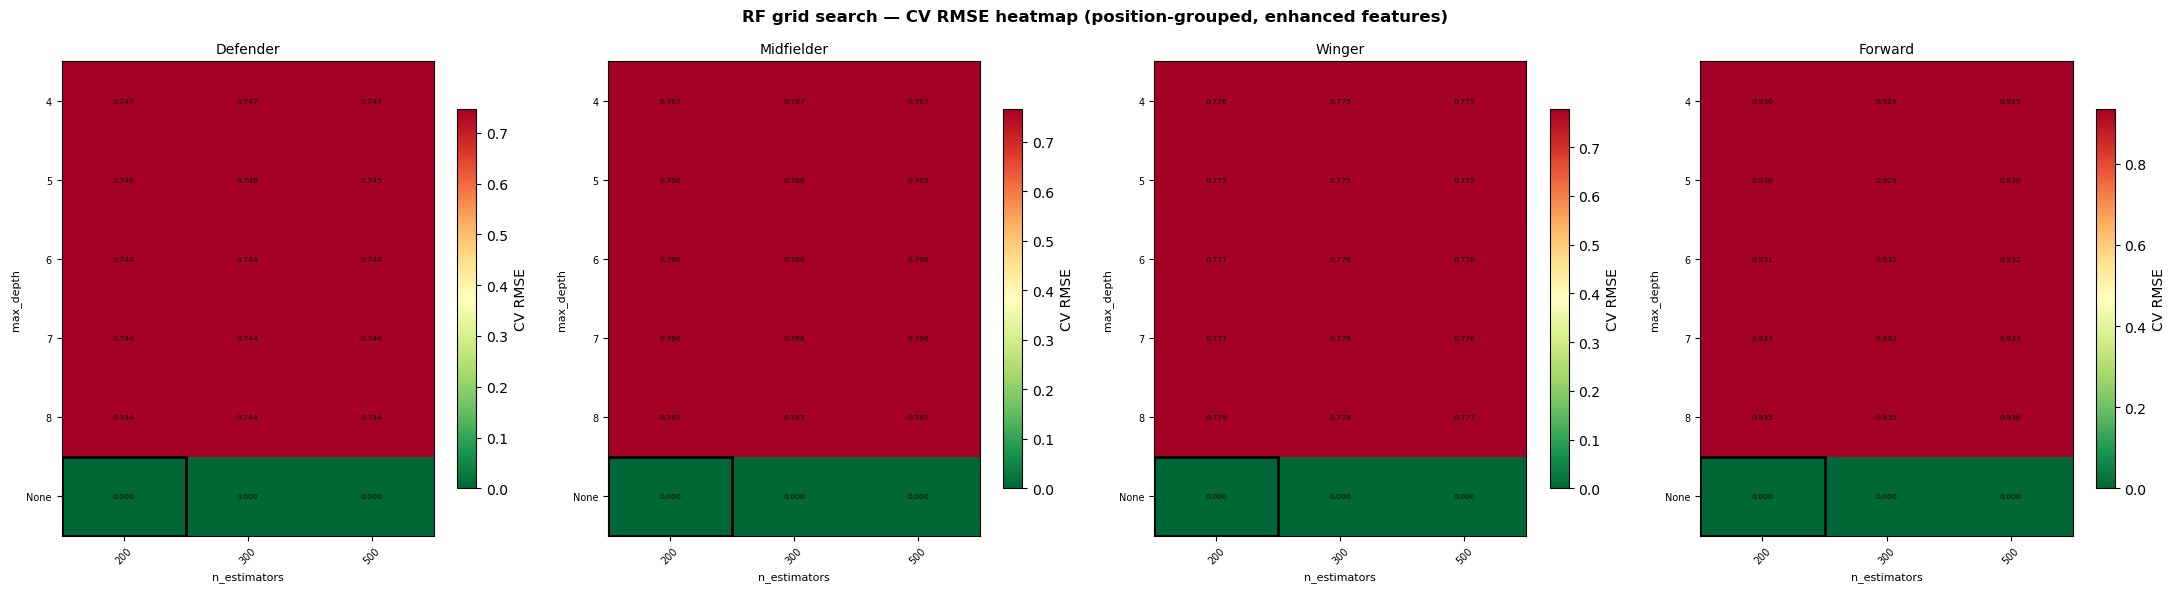

In [177]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle('RF grid search — CV RMSE heatmap (position-grouped, enhanced features)',
             fontsize=12, fontweight='bold')

for ax, group in zip(axes, GROUPS):
    df_grid = grid_results_enh_grouped[group]
    n_vals  = sorted(df_grid['n_estimators'].unique())
    d_vals  = sorted([d for d in df_grid['max_depth'].unique() if d is not None]) + [None]
    matrix  = np.zeros((len(d_vals), len(n_vals)))

    for i, d in enumerate(d_vals):
        for j, n in enumerate(n_vals):
            val = df_grid[(df_grid['n_estimators'] == n) &
                          (df_grid['max_depth'] == d)]['cv_rmse'].values
            if len(val) > 0:
                matrix[i, j] = val[0]

    im = ax.imshow(matrix, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(len(n_vals)))
    ax.set_xticklabels(n_vals, fontsize=7, rotation=45)
    ax.set_yticks(range(len(d_vals)))
    ax.set_yticklabels([str(d) for d in d_vals], fontsize=7)
    ax.set_xlabel('n_estimators', fontsize=8)
    ax.set_ylabel('max_depth', fontsize=8)
    ax.set_title(f'{group.capitalize()}', fontsize=10)

    best_idx = np.unravel_index(matrix.argmin(), matrix.shape)
    ax.add_patch(plt.Rectangle((best_idx[1]-0.5, best_idx[0]-0.5),
                                1, 1, fill=False, edgecolor='black', lw=2))

    for i in range(len(d_vals)):
        for j in range(len(n_vals)):
            ax.text(j, i, f'{matrix[i,j]:.3f}', ha='center', va='center',
                    fontsize=5.5, color='black')
    plt.colorbar(im, ax=ax, shrink=0.8, label='CV RMSE')

plt.tight_layout()
plt.savefig(MODELS_DIR / 'rf_grid_grouped_enhanced_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [178]:
print('=' * 72)
print('  FULL COMPARISON — ALL EXPERIMENTS')
print('=' * 72)

def avg_r2(results):
    return np.mean([r['r2'] for r in results])

def avg_rmse(results):
    return np.mean([r['rmse'] for r in results])

comparison_rows = [
    ('Baseline mean',                        results_baseline[0]['rmse'],           results_baseline[0]['r2'],  'N/A'),
    ('Ridge — single, baseline features',    results_ridge_single[0]['rmse'],       results_ridge_single[0]['r2'],  f'alpha={ridge_single_out.alpha_}'),
    ('RF — single, baseline features',       results_rf_single[0]['rmse'],          results_rf_single[0]['r2'],     f'n={best_params_out_single["n_estimators"]} d={best_params_out_single["max_depth"]}'),
    ('Ridge — grouped, baseline features',   avg_rmse(results_ridge_grouped),       avg_r2(results_ridge_grouped),  f'alpha={[ridge_grouped_models[g].alpha_ for g in GROUPS]}'),
    ('RF — grouped, baseline features',      avg_rmse(results_rf_grouped),          avg_r2(results_rf_grouped),     f'n/d per group below'),
    ('Ridge — single, enhanced features',    results_ridge_enh_single[0]['rmse'],   results_ridge_enh_single[0]['r2'],  f'alpha={ridge_enh_single_out.alpha_}'),
    ('RF — single, enhanced features',       results_rf_enh_single[0]['rmse'],      results_rf_enh_single[0]['r2'],     f'n={best_params_out_enh["n_estimators"]} d={best_params_out_enh["max_depth"]}'),
    ('Ridge — grouped, enhanced features',   avg_rmse(results_ridge_enh_grouped),   avg_r2(results_ridge_enh_grouped),  f'alpha per group below'),
    ('RF — grouped, enhanced features ★',   avg_rmse(results_rf_enh_grouped),      avg_r2(results_rf_enh_grouped),     f'n/d per group below'),
]

print(f'\n  {"Model":<45} {"Avg RMSE":>10} {"Avg R²":>8}  Hyperparams')
print(f'  {"-"*90}')
for label, rmse, r2, hparams in comparison_rows:
    marker = ' ← BEST' if '★' in label else ''
    print(f'  {label:<45} {rmse:>10.4f} {r2:>8.4f}  {hparams}{marker}')

# ── Per position breakdown — best model ───────────────────────
print(f'\n── Best model (RF grouped enhanced) — per position ──')
print(f'  {"Position":<15} {"RMSE":>8} {"R²":>8}  {"n_estimators":>14} {"max_depth":>10}')
print(f'  {"-"*58}')
for r in results_rf_enh_grouped:
    group  = r['label'].split('— ')[1]
    params = rf_enh_grouped_models[group]['params']
    print(f'  {group:<15} {r["rmse"]:>8.4f} {r["r2"]:>8.4f}  '
          f'{params["n_estimators"]:>14} {str(params["max_depth"]):>10}')

# ── Ridge per position — enhanced ─────────────────────────────
print(f'\n── Ridge grouped enhanced — alpha per position ──')
print(f'  {"Position":<15} {"RMSE":>8} {"R²":>8}  {"alpha":>10}')
print(f'  {"-"*45}')
for r in results_ridge_enh_grouped:
    group = r['label'].split('— ')[1]
    alpha = ridge_enh_grouped_models[group].alpha_
    print(f'  {group:<15} {r["rmse"]:>8.4f} {r["r2"]:>8.4f}  {alpha:>10}')

# ── GK comparison ─────────────────────────────────────────────
print(f'\n── GK models ──')
print(f'  {"Model":<45} {"RMSE":>10} {"R²":>8}  Hyperparams')
print(f'  {"-"*80}')
gk_comparison = [
    ('Ridge — single, baseline features', results_ridge_single[1],     f'alpha={ridge_single_gk.alpha_}'),
    ('RF — single, baseline features',    results_rf_single[1],        f'n={best_params_gk_single["n_estimators"]} d={best_params_gk_single["max_depth"]}'),
    ('Ridge — single, enhanced features', results_ridge_enh_single[1], f'alpha={ridge_enh_single_gk.alpha_}'),
    ('RF — single, enhanced features',    results_rf_enh_single[1],    f'n={best_params_gk_enh["n_estimators"]} d={best_params_gk_enh["max_depth"]}'),
]
for label, r, hparams in gk_comparison:
    print(f'  {label:<45} {r["rmse"]:>10.4f} {r["r2"]:>8.4f}  {hparams}')

  FULL COMPARISON — ALL EXPERIMENTS

  Model                                           Avg RMSE   Avg R²  Hyperparams
  ------------------------------------------------------------------------------------------
  Baseline mean                                     0.7944  -0.0011  N/A
  Ridge — single, baseline features                 0.7764   0.0440  alpha=2000.0
  RF — single, baseline features                    0.7694   0.0610  n=200 d=6
  Ridge — grouped, baseline features                0.7845   0.0515  alpha=[np.float64(2000.0), np.float64(750.0), np.float64(2000.0), np.float64(1000.0)]
  RF — grouped, baseline features                   0.7795   0.0634  n/d per group below
  Ridge — single, enhanced features                 0.7607   0.0823  alpha=750.0
  RF — single, enhanced features                    0.7580   0.0886  n=500 d=8
  Ridge — grouped, enhanced features                0.7733   0.0791  alpha per group below
  RF — grouped, enhanced features ★                 0.7696  

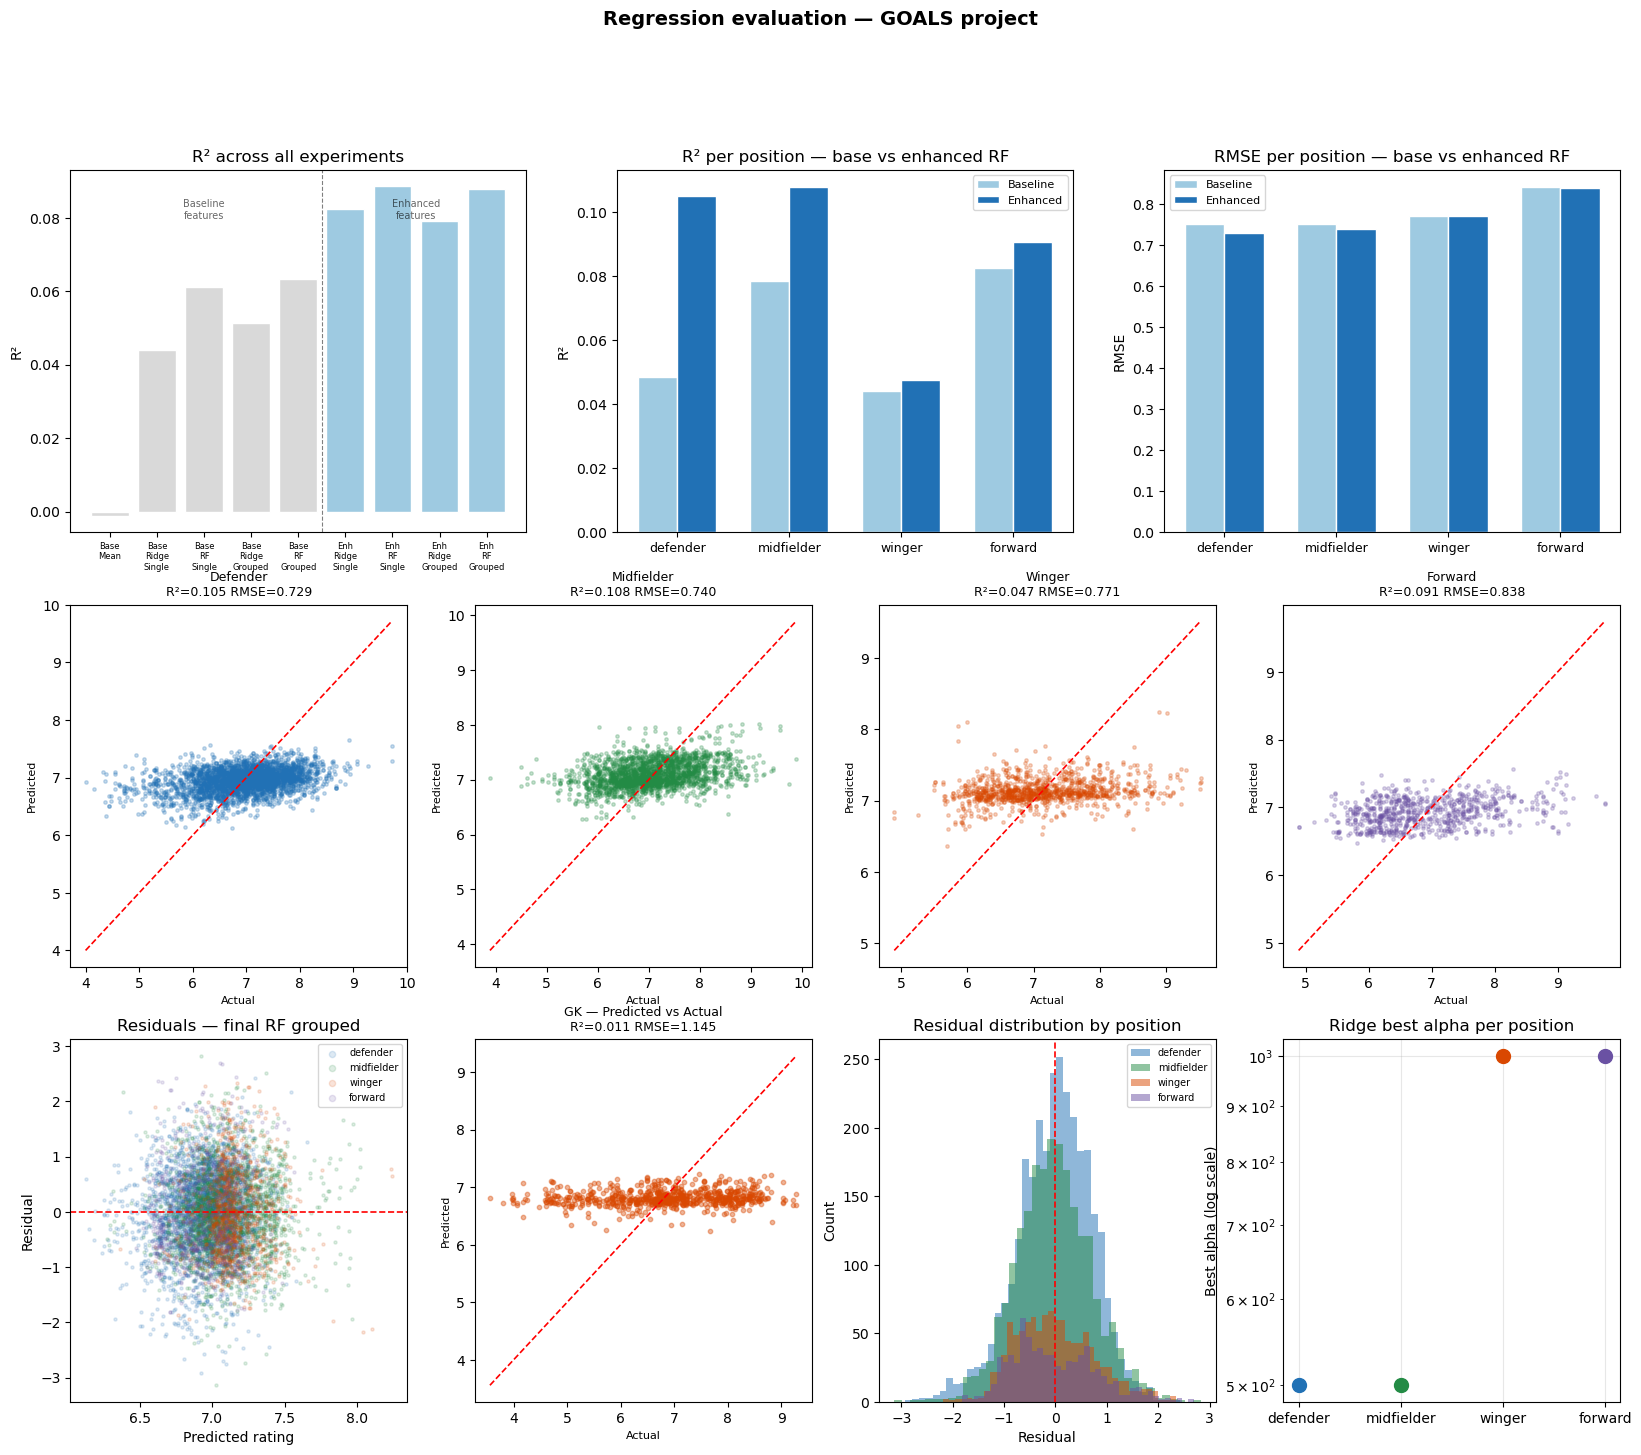

Saved to data/models/regression_full_evaluation.png


In [179]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Regression evaluation — GOALS project', fontsize=14, fontweight='bold')

# ── Plot 1: R² progression ────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
labels = ['Base\nMean', 'Base\nRidge\nSingle', 'Base\nRF\nSingle',
          'Base\nRidge\nGrouped', 'Base\nRF\nGrouped',
          'Enh\nRidge\nSingle', 'Enh\nRF\nSingle',
          'Enh\nRidge\nGrouped', 'Enh\nRF\nGrouped']
r2_vals = [r[2] for r in comparison_rows]
colors  = ['#d9d9d9']*5 + ['#9ecae1']*4
bars    = ax1.bar(range(len(labels)), r2_vals, color=colors, edgecolor='white')
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, fontsize=6)
ax1.set_ylabel('R²')
ax1.set_title('R² across all experiments')
ax1.axvline(4.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.text(2, max(r2_vals)*0.9, 'Baseline\nfeatures', ha='center', fontsize=7, alpha=0.6)
ax1.text(6.5, max(r2_vals)*0.9, 'Enhanced\nfeatures', ha='center', fontsize=7, alpha=0.6)

# ── Plot 2: R² per position — base vs enhanced grouped RF ─────
ax2 = fig.add_subplot(3, 3, 2)
x       = np.arange(len(GROUPS))
width   = 0.35
r2_base = [r['r2'] for r in results_rf_grouped]
r2_enh  = [r['r2'] for r in results_rf_enh_grouped]
ax2.bar(x - width/2, r2_base, width, label='Baseline', color='#9ecae1', edgecolor='white')
ax2.bar(x + width/2, r2_enh,  width, label='Enhanced', color='#2171b5', edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(GROUPS, fontsize=9)
ax2.set_ylabel('R²')
ax2.set_title('R² per position — base vs enhanced RF')
ax2.legend(fontsize=8)

# ── Plot 3: RMSE per position ─────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
rmse_base = [r['rmse'] for r in results_rf_grouped]
rmse_enh  = [r['rmse'] for r in results_rf_enh_grouped]
ax3.bar(x - width/2, rmse_base, width, label='Baseline', color='#9ecae1', edgecolor='white')
ax3.bar(x + width/2, rmse_enh,  width, label='Enhanced', color='#2171b5', edgecolor='white')
ax3.set_xticks(x)
ax3.set_xticklabels(GROUPS, fontsize=9)
ax3.set_ylabel('RMSE')
ax3.set_title('RMSE per position — base vs enhanced RF')
ax3.legend(fontsize=8)

# ── Plots 4-7: Predicted vs Actual per position (final model) ─
for idx, group in enumerate(GROUPS):
    ax = fig.add_subplot(3, 4, 5 + idx)
    test_g   = outfield_test[outfield_test['position_group'] == group]
    _, preds = y_pred_test_final[group]
    actuals  = test_g['rating_title'].values
    ax.scatter(actuals, preds, alpha=0.25, s=6, color=GROUP_COLS[group])
    mn, mx = actuals.min(), actuals.max()
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.2)
    r2   = r2_score(actuals, preds)
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    ax.set_title(f'{group.capitalize()}\nR²={r2:.3f} RMSE={rmse:.3f}', fontsize=9)
    ax.set_xlabel('Actual', fontsize=8)
    ax.set_ylabel('Predicted', fontsize=8)

# ── Plot 8: Residuals all positions ───────────────────────────
ax8 = fig.add_subplot(3, 4, 9)
for group in GROUPS:
    test_g   = outfield_test[outfield_test['position_group'] == group]
    _, preds = y_pred_test_final[group]
    residuals = test_g['rating_title'].values - preds
    ax8.scatter(preds, residuals, alpha=0.15, s=5,
                color=GROUP_COLS[group], label=group)
ax8.axhline(0, color='red', linestyle='--', linewidth=1.2)
ax8.set_xlabel('Predicted rating')
ax8.set_ylabel('Residual')
ax8.set_title('Residuals — final RF grouped')
ax8.legend(fontsize=7, markerscale=2)

# ── Plot 9: GK predicted vs actual ───────────────────────────
ax9 = fig.add_subplot(3, 4, 10)
ax9.scatter(y_test_gk, y_pred_rf_enh_gk, alpha=0.4, s=10, color='#d94801')
mn, mx = y_test_gk.min(), y_test_gk.max()
ax9.plot([mn, mx], [mn, mx], 'r--', linewidth=1.2)
gk_r2   = r2_score(y_test_gk, y_pred_rf_enh_gk)
gk_rmse = np.sqrt(mean_squared_error(y_test_gk, y_pred_rf_enh_gk))
ax9.set_title(f'GK — Predicted vs Actual\nR²={gk_r2:.3f} RMSE={gk_rmse:.3f}', fontsize=9)
ax9.set_xlabel('Actual', fontsize=8)
ax9.set_ylabel('Predicted', fontsize=8)

# ── Plot 10: Residual distribution ────────────────────────────
ax10 = fig.add_subplot(3, 4, 11)
all_residuals = []
all_colors    = []
for group in GROUPS:
    test_g   = outfield_test[outfield_test['position_group'] == group]
    _, preds = y_pred_test_final[group]
    residuals = test_g['rating_title'].values - preds
    ax10.hist(residuals, bins=40, alpha=0.5, color=GROUP_COLS[group],
              label=group, edgecolor='none')
ax10.axvline(0, color='red', linestyle='--', linewidth=1.2)
ax10.set_xlabel('Residual')
ax10.set_ylabel('Count')
ax10.set_title('Residual distribution by position')
ax10.legend(fontsize=7)

# ── Plot 11: Ridge alpha selection ───────────────────────────
ax11 = fig.add_subplot(3, 4, 12)
for group in GROUPS:
    alpha = ridge_enh_grouped_models[group].alpha_
    ax11.scatter([group], [alpha], color=GROUP_COLS[group], s=100, zorder=5)
ax11.set_yscale('log')
ax11.set_ylabel('Best alpha (log scale)')
ax11.set_title('Ridge best alpha per position')
ax11.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'regression_full_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/models/regression_full_evaluation.png')

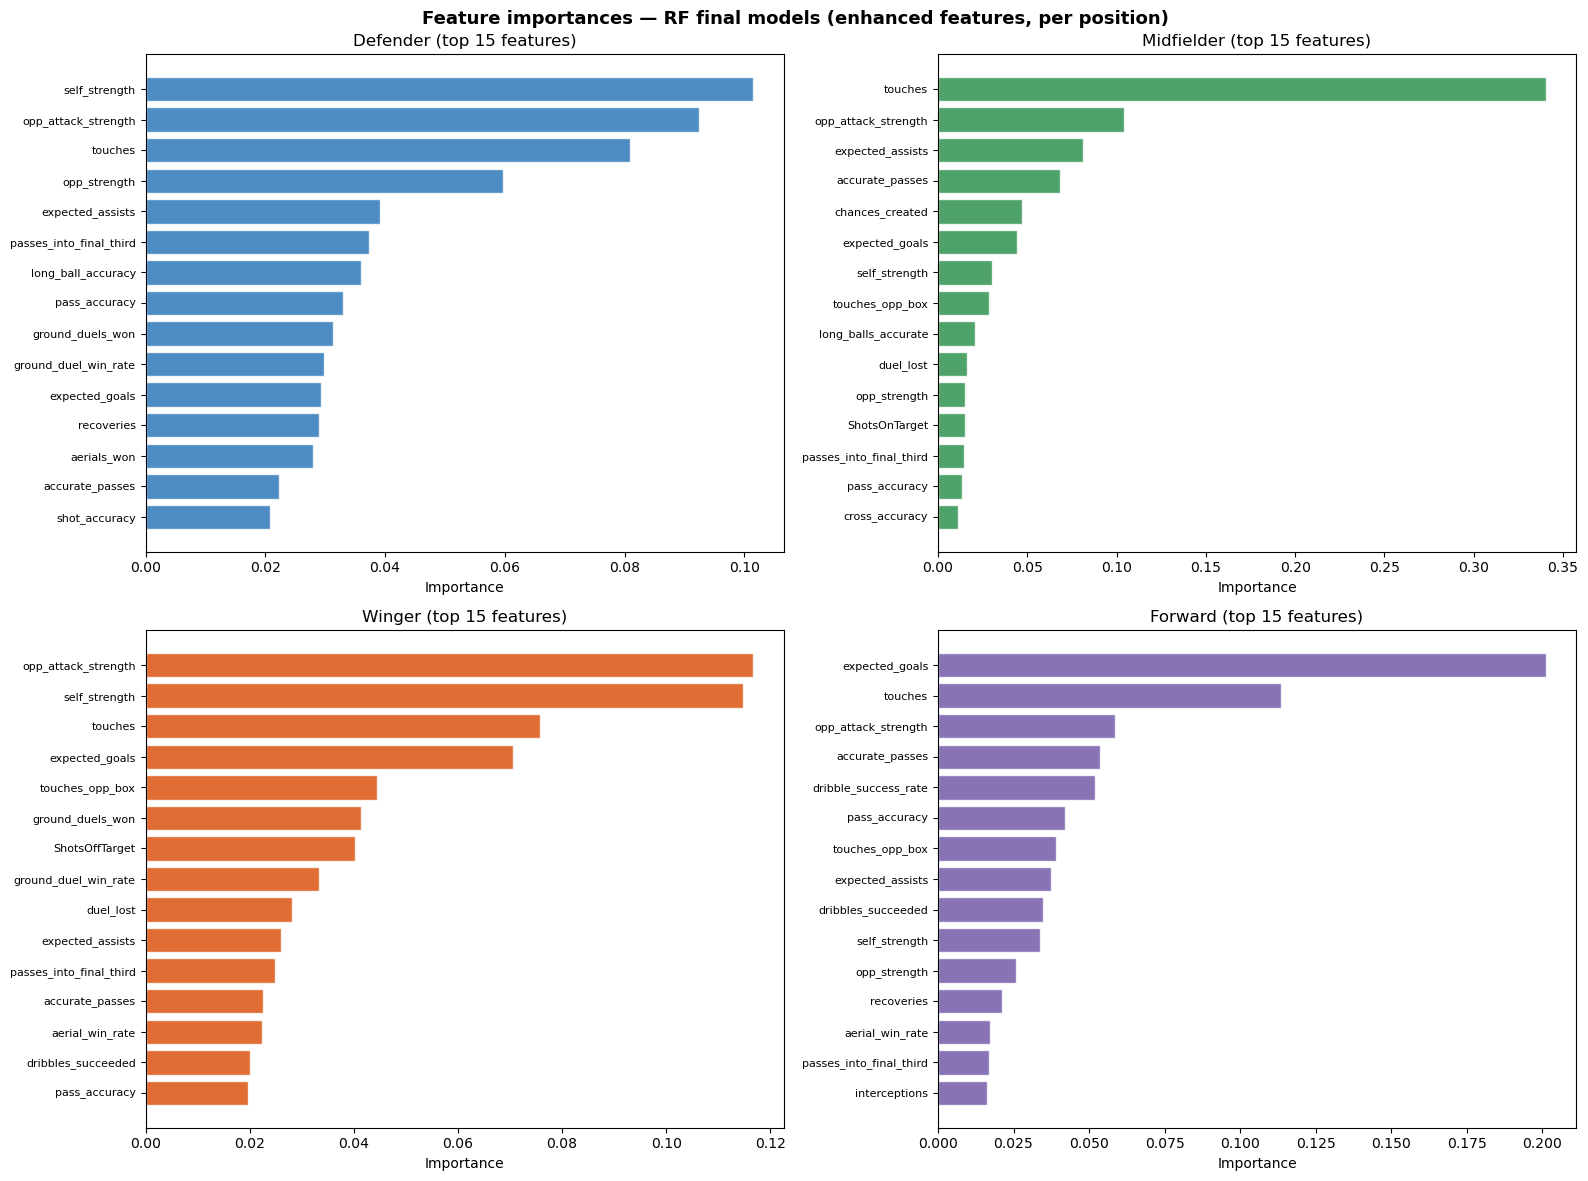

In [180]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Feature importances — RF final models (enhanced features, per position)',
             fontsize=13, fontweight='bold')

for ax, group in zip(axes.flatten(), GROUPS):
    rf      = rf_enh_grouped_models[group]['model']
    imps    = rf.feature_importances_
    indices = np.argsort(imps)[-15:]

    ax.barh(range(15), imps[indices], color=GROUP_COLS[group], alpha=0.8, edgecolor='white')
    ax.set_yticks(range(15))
    ax.set_yticklabels([FEATURE_COLS_ENH_OUT[i] for i in indices], fontsize=8)
    ax.set_xlabel('Importance')
    ax.set_title(f'{group.capitalize()} (top 15 features)')

plt.tight_layout()
plt.savefig(MODELS_DIR / 'feature_importances_final.png', dpi=150, bbox_inches='tight')
plt.show()

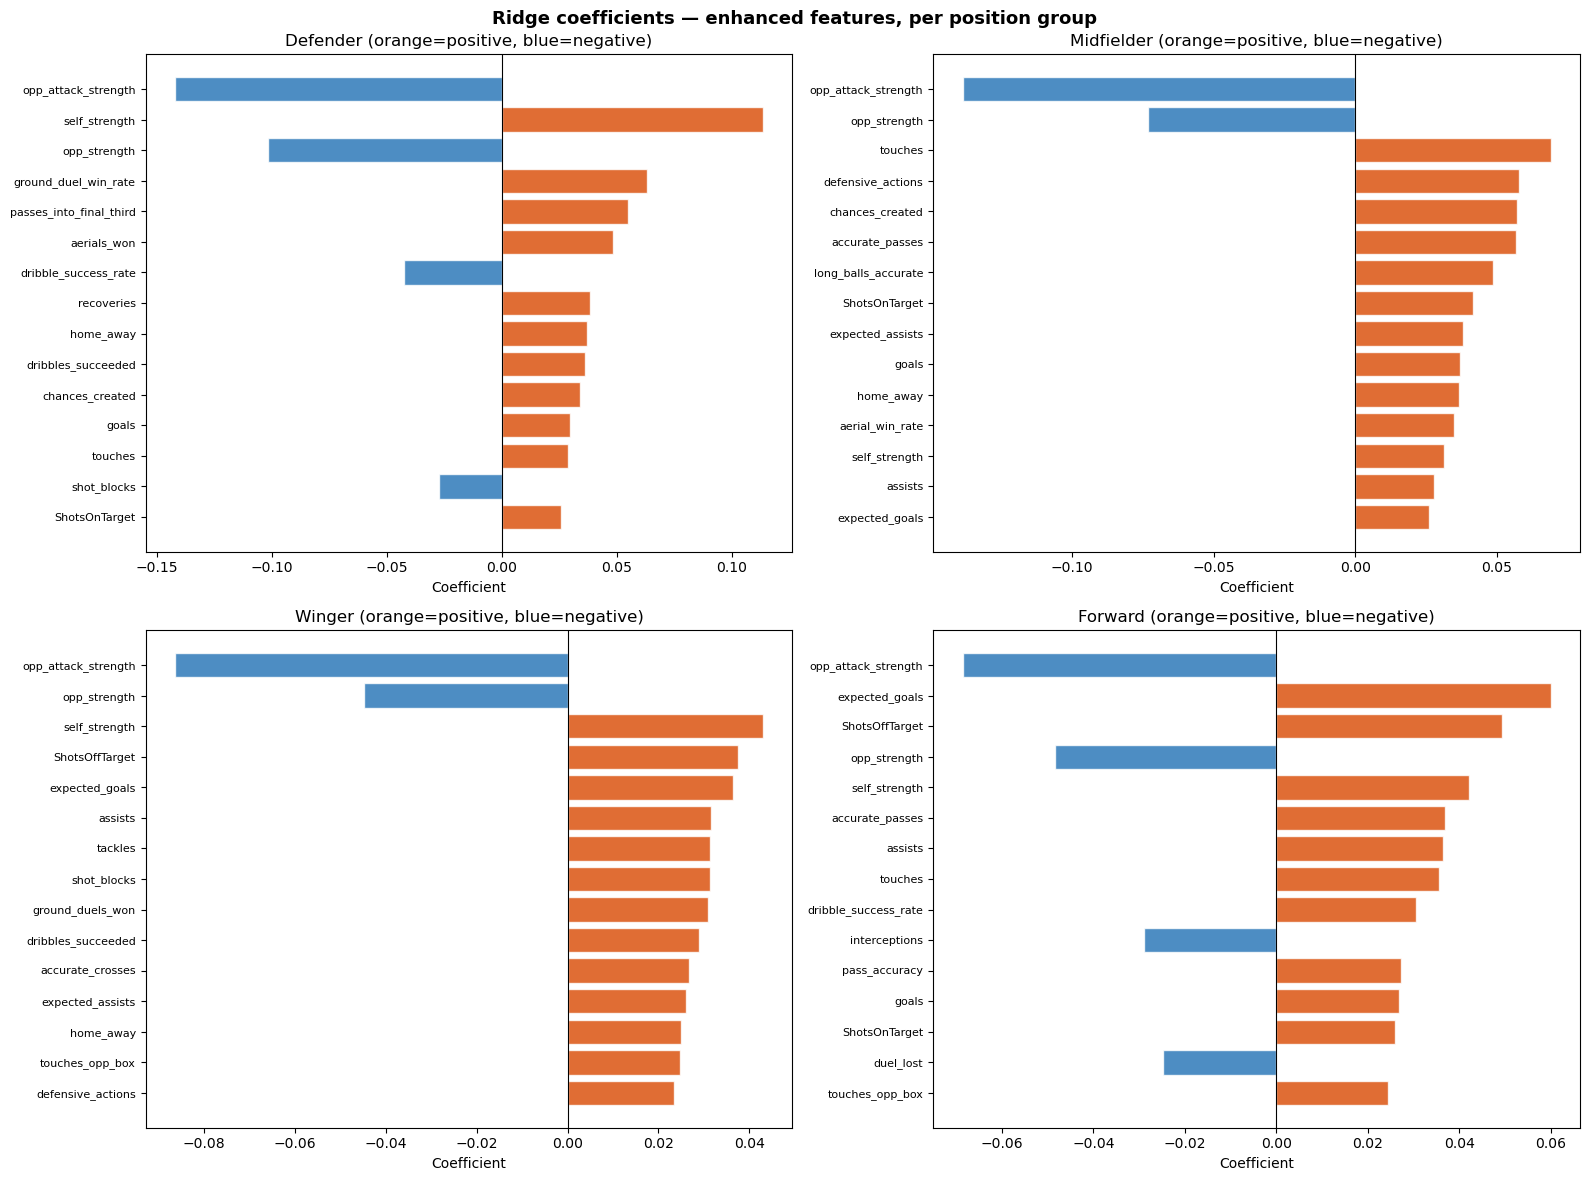

In [181]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Ridge coefficients — enhanced features, per position group',
             fontsize=13, fontweight='bold')

for ax, group in zip(axes.flatten(), GROUPS):
    ridge   = ridge_enh_grouped_models[group]
    coefs   = ridge.coef_
    indices = np.argsort(np.abs(coefs))[-15:]
    colors  = ['#d94801' if coefs[i] > 0 else '#2171b5' for i in indices]

    ax.barh(range(15), coefs[indices], color=colors, alpha=0.8, edgecolor='white')
    ax.set_yticks(range(15))
    ax.set_yticklabels([FEATURE_COLS_ENH_OUT[i] for i in indices], fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Coefficient')
    ax.set_title(f'{group.capitalize()} (orange=positive, blue=negative)')

plt.tight_layout()
plt.savefig(MODELS_DIR / 'ridge_coefficients_final.png', dpi=150, bbox_inches='tight')
plt.show()

In [182]:
# ── Save models ───────────────────────────────────────────────
joblib.dump({g: rf_enh_grouped_models[g]['model'] for g in GROUPS},
            MODELS_DIR / 'rf_outfield_grouped_final.pkl')
joblib.dump({g: rf_grouped_models[g]['model'] for g in GROUPS},
            MODELS_DIR / 'rf_outfield_grouped_baseline.pkl')
joblib.dump(ridge_enh_grouped_models,  MODELS_DIR / 'ridge_outfield_grouped_final.pkl')
joblib.dump(ridge_grouped_models,      MODELS_DIR / 'ridge_outfield_grouped_baseline.pkl')
joblib.dump(rf_enh_single_gk,          MODELS_DIR / 'rf_gk_final.pkl')
joblib.dump(ridge_enh_single_gk,       MODELS_DIR / 'ridge_gk_final.pkl')
joblib.dump(FEATURE_COLS_ENH_OUT,      MODELS_DIR / 'feature_cols_outfield_final.pkl')
joblib.dump(FEATURE_COLS_ENH_GK,       MODELS_DIR / 'feature_cols_gk_final.pkl')

# ── Add predictions to dataframes ────────────────────────────
for df_name, df in [('outfield_train', outfield_train),
                     ('outfield_test',  outfield_test)]:
    df['pred_rating_ridge_base'] = np.nan
    df['pred_rating_rf_base']    = np.nan
    df['pred_rating_ridge_enh']  = np.nan
    df['pred_rating_rf_enh']     = np.nan

    for group in GROUPS:
        mask   = df['position_group'] == group
        X_base = df.loc[mask, FEATURE_COLS_OUT].values
        X_enh  = df.loc[mask, FEATURE_COLS_ENH_OUT].values

        df.loc[mask, 'pred_rating_ridge_base'] = ridge_grouped_models[group].predict(X_base)
        df.loc[mask, 'pred_rating_rf_base']    = rf_grouped_models[group]['model'].predict(X_base)
        df.loc[mask, 'pred_rating_ridge_enh']  = ridge_enh_grouped_models[group].predict(X_enh)
        df.loc[mask, 'pred_rating_rf_enh']     = rf_enh_grouped_models[group]['model'].predict(X_enh)

    globals()[df_name] = df

gk_train['pred_rating_ridge_enh'] = ridge_enh_single_gk.predict(X_train_gk_e)
gk_train['pred_rating_rf_enh']    = rf_enh_single_gk.predict(X_train_gk_e)
gk_test['pred_rating_ridge_enh']  = ridge_enh_single_gk.predict(X_test_gk_e)
gk_test['pred_rating_rf_enh']     = rf_enh_single_gk.predict(X_test_gk_e)

# ── Export parquets ───────────────────────────────────────────
outfield_train.to_parquet(PROCESSED_DIR / 'outfield_train_with_predictions.parquet', index=False)
outfield_test.to_parquet(PROCESSED_DIR  / 'outfield_test_with_predictions.parquet',  index=False)
gk_train.to_parquet(PROCESSED_DIR       / 'gk_train_with_predictions.parquet',       index=False)
gk_test.to_parquet(PROCESSED_DIR        / 'gk_test_with_predictions.parquet',        index=False)

print('Models saved to data/models/:')
for f in sorted(MODELS_DIR.glob('*.pkl')):
    print(f'  {f.name}')

print('\nPrediction parquets saved:')
for name in ['outfield_train_with_predictions', 'outfield_test_with_predictions',
             'gk_train_with_predictions', 'gk_test_with_predictions']:
    p = PROCESSED_DIR / f'{name}.parquet'
    print(f'  {name}.parquet — {pd.read_parquet(p).shape}')

Models saved to data/models/:
  feature_cols_gk_final.pkl
  feature_cols_outfield_final.pkl
  position_map.pkl
  rf_gk_final.pkl
  rf_outfield_grouped_baseline.pkl
  rf_outfield_grouped_final.pkl
  ridge_gk_final.pkl
  ridge_outfield_grouped_baseline.pkl
  ridge_outfield_grouped_final.pkl
  scaler_gk.pkl
  scalers_outfield.pkl

Prediction parquets saved:
  outfield_train_with_predictions.parquet — (21847, 64)
  outfield_test_with_predictions.parquet — (7034, 64)
  gk_train_with_predictions.parquet — (2193, 49)
  gk_test_with_predictions.parquet — (713, 49)
